### Quick data glimpse / structure check

- Read CSV data into pandas DataFrames.
- Preview a few rows.

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
df1 = pd.read_csv("Raw/dataset1.csv")
df2 = pd.read_csv("Raw/dataset2.csv")

# Preview
print("Dataset 1 head:")
display(df1.head())
print("Dataset 2 head:")
display(df2.head())


Dataset 1 head:


,start_time,bat_landing_to_food,habit,rat_period_start,rat_period_end,seconds_after_rat_arrival,risk,reward,month,sunset_time,hours_after_sunset,season
0,30/12/2017 18:37,16.000000,rat,30/12/2017 18:35,30/12/2017 18:38,108,1,0,0,30/12/2017 16:45,1.870833,0
1,30/12/2017 19:51,0.074016,fast,30/12/2017 19:50,30/12/2017 19:55,17,0,1,0,30/12/2017 16:45,3.100833,0
2,30/12/2017 19:51,4.000000,fast,30/12/2017 19:50,30/12/2017 19:55,41,0,1,0,30/12/2017 16:45,3.107500,0
3,30/12/2017 19:52,10.000000,rat,30/12/2017 19:50,30/12/2017 19:55,111,1,0,0,30/12/2017 16:45,3.126944,0
4,30/12/2017 19:54,15.000000,rat,30/12/2017 19:50,30/12/2017 19:55,194,1,0,0,30/12/2017 16:45,3.150000,0


Dataset 2 head:


,time,month,hours_after_sunset,bat_landing_number,food_availability,rat_minutes,rat_arrival_number
0,26/12/2017 16:13,0,-0.5,20,4.000000,0.0,0
1,26/12/2017 16:43,0,0.0,28,4.000000,0.0,0
2,26/12/2017 17:13,0,0.5,25,4.000000,0.0,0
3,26/12/2017 17:43,0,1.0,71,4.000000,0.0,0
4,26/12/2017 18:13,0,1.5,44,3.753857,0.0,0


### Cleaning & preprocessing

- Remove duplicate records.

In [2]:
# DATA QUALITY ASSESSMENT
print("=== INITIAL DATA ASSESSMENT ===")
print(f"Dataset 1: {df1.shape[0]} rows, {df1.shape[1]} columns")
print(f"Dataset 2: {df2.shape[0]} rows, {df2.shape[1]} columns")

# Store original metrics for comparison
original_df1_shape = df1.shape
original_df2_shape = df2.shape
original_df1_nulls = df1.isnull().sum().sum()
original_df2_nulls = df2.isnull().sum().sum()

print(f"\nMissing values - Dataset 1: {original_df1_nulls}")
print(f"Missing values - Dataset 2: {original_df2_nulls}")

print(f"\nDuplicates - Dataset 1: {df1.duplicated().sum()}")
print(f"Duplicates - Dataset 2: {df2.duplicated().sum()}")

=== INITIAL DATA ASSESSMENT ===
Dataset 1: 907 rows, 12 columns
Dataset 2: 2123 rows, 7 columns

Missing values - Dataset 1: 41
Missing values - Dataset 2: 0

Duplicates - Dataset 1: 1
Duplicates - Dataset 2: 0


### Cleaning & preprocessing

- Fix/convert data types.
- Normalize string or category values.
- Trim whitespace from text fields.
- Lowercase text for standardisation.

In [3]:
def clean_columns(df):
    df.columns = (
        df.columns.astype(str)
                  .str.strip()
                  .str.lower()
                  .str.replace(r"[^\w\s]", "", regex=True)
                  .str.replace(r"\s+", "_", regex=True)
    )
    return df

df1 = clean_columns(df1)
df2 = clean_columns(df2)


### Cleaning & preprocessing

- Fix/convert data types.
- Trim whitespace from text fields.

In [4]:
for col in df1.select_dtypes(include="object").columns:
    df1[col] = df1[col].astype(str).str.strip()

for col in df2.select_dtypes(include="object").columns:
    df2[col] = df2[col].astype(str).str.strip()

    

### Datetime parsing & time features

- Parse timestamps into datetime.

In [5]:
# Date conversion
# Dataset1
for col in ["start_time","rat_period_start","rat_period_end","sunset_time"]:
    if col in df1.columns:
        df1[col] = pd.to_datetime(df1[col], errors="coerce", dayfirst=True)

# Dataset2
if "time" in df2.columns:
    df2["time"] = pd.to_datetime(df2["time"], errors="coerce", dayfirst=True)


In [6]:
# Numeric conversion
# Dataset1 numeric columns
for col in ["bat_landing_to_food","seconds_after_rat_arrival","risk","reward","hours_after_sunset"]:
    if col in df1.columns:
        df1[col] = pd.to_numeric(df1[col], errors="coerce")

# Dataset2 numeric columns
for col in ["hours_after_sunset","bat_landing_number","food_availability","rat_minutes","rat_arrival_number"]:
    if col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors="coerce")

        

### Cleaning & preprocessing

- Remove duplicate records.

In [7]:
# Remove duplicates
df1 = df1.drop_duplicates().reset_index(drop=True)
df2 = df2.drop_duplicates().reset_index(drop=True)

In [8]:
# DATA CONSISTENCY VALIDATION
print("=== CONSISTENCY CHECKS ===")

# Check date logic in Dataset 1
if 'start_time' in df1.columns and 'rat_period_start' in df1.columns:
    date_issues = df1[df1['start_time'] < df1['rat_period_start']].shape[0]
    print(f"Bat arrivals before rat period starts: {date_issues}")

# Check risk/reward exclusivity
if 'risk' in df1.columns and 'reward' in df1.columns:
    both_risk_reward = df1[(df1['risk'] == 1) & (df1['reward'] == 1)].shape[0]
    print(f"Records with both risk=1 AND reward=1: {both_risk_reward}")

# Check hours_after_sunset consistency
negative_hours_df1 = df1[df1['hours_after_sunset'] < 0].shape[0] if 'hours_after_sunset' in df1.columns else 0
negative_hours_df2 = df2[df2['hours_after_sunset'] < 0].shape[0] if 'hours_after_sunset' in df2.columns else 0
print(f"Negative hours_after_sunset - Dataset 1: {negative_hours_df1}, Dataset 2: {negative_hours_df2}")

=== CONSISTENCY CHECKS ===
Bat arrivals before rat period starts: 0
Records with both risk=1 AND reward=1: 98
Negative hours_after_sunset - Dataset 1: 12, Dataset 2: 212


### Filter, group & aggregate

- Numeric transforms with NumPy.
- Select/filter rows/columns.

In [9]:
# Data validation rules
# Risk / Reward must be 0 or 1
for col in ["risk","reward"]:
    if col in df1.columns:
        df1.loc[~df1[col].isin([0,1]), col] = np.nan

# Remove negative values
for col in ["bat_landing_to_food","seconds_after_rat_arrival","hours_after_sunset"]:
    if col in df1.columns:
        df1.loc[df1[col] < 0, col] = np.nan

for col in ["hours_after_sunset","rat_minutes"]:
    if col in df2.columns:
        df2.loc[df2[col] < 0, col] = np.nan

# Cap hours_after_sunset to 24h
for df in [df1, df2]:
    if "hours_after_sunset" in df.columns:
        df.loc[df["hours_after_sunset"] > 24, "hours_after_sunset"] = np.nan

        
        

In [10]:
# OUTLIER DETECTION
def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("=== OUTLIER ANALYSIS ===")
outlier_columns = ['bat_landing_to_food', 'seconds_after_rat_arrival', 'hours_after_sunset']

for col in outlier_columns:
    if col in df1.columns:
        outliers, lower, upper = detect_outliers_iqr(df1, col)
        print(f"{col}: {len(outliers)} outliers detected (bounds: {lower:.2f} - {upper:.2f})")
        # Optionally cap extreme outliers
        extreme_outliers = len(df1[df1[col] > upper + 2*(upper-lower)])
        if extreme_outliers > 0:
            print(f"  - {extreme_outliers} extreme outliers beyond 2*IQR")

=== OUTLIER ANALYSIS ===
bat_landing_to_food: 88 outliers detected (bounds: -15.12 - 27.88)
  - 12 extreme outliers beyond 2*IQR
seconds_after_rat_arrival: 0 outliers detected (bounds: -447.75 - 984.25)
hours_after_sunset: 0 outliers detected (bounds: -1.59 - 12.83)


In [11]:
# CLEANING IMPACT SUMMARY
final_df1_shape = df1.shape
final_df2_shape = df2.shape
final_df1_nulls = df1.isnull().sum().sum()
final_df2_nulls = df2.isnull().sum().sum()

print("=== CLEANING SUMMARY REPORT ===")
print(f"Dataset 1:")
print(f"  Rows: {original_df1_shape[0]} → {final_df1_shape[0]} (removed: {original_df1_shape[0] - final_df1_shape[0]})")
print(f"  Missing values: {original_df1_nulls} → {final_df1_nulls} (change: {final_df1_nulls - original_df1_nulls})")

print(f"\nDataset 2:")
print(f"  Rows: {original_df2_shape[0]} → {final_df2_shape[0]} (removed: {original_df2_shape[0] - final_df2_shape[0]})")
print(f"  Missing values: {original_df2_nulls} → {final_df2_nulls} (change: {final_df2_nulls - original_df2_nulls})")

=== CLEANING SUMMARY REPORT ===
Dataset 1:
  Rows: 907 → 906 (removed: 1)
  Missing values: 41 → 12 (change: -29)

Dataset 2:
  Rows: 2123 → 2123 (removed: 0)
  Missing values: 0 → 212 (change: 212)


In [12]:
# Data quality score
completeness_df1 = 1 - (final_df1_nulls / (final_df1_shape[0] * final_df1_shape[1]))
completeness_df2 = 1 - (final_df2_nulls / (final_df2_shape[0] * final_df2_shape[1]))

print(f"\nData Completeness Scores:")
print(f"  Dataset 1: {completeness_df1:.1%}")
print(f"  Dataset 2: {completeness_df2:.1%}")


Data Completeness Scores:
  Dataset 1: 99.9%
  Dataset 2: 98.6%


In [13]:
df1.head()
df2.head()

,time,month,hours_after_sunset,bat_landing_number,food_availability,rat_minutes,rat_arrival_number
0,2017-12-26 16:13:00,0,NaN,20,4.000000,0.0,0
1,2017-12-26 16:43:00,0,0.0,28,4.000000,0.0,0
2,2017-12-26 17:13:00,0,0.5,25,4.000000,0.0,0
3,2017-12-26 17:43:00,0,1.0,71,4.000000,0.0,0
4,2017-12-26 18:13:00,0,1.5,44,3.753857,0.0,0


## Risk-Taking vs Avoidance
This chart shows how many bats took risks (1) or avoided them (0) during their landings.  
It helps us understand whether bats generally behave boldly or cautiously when rats are present.

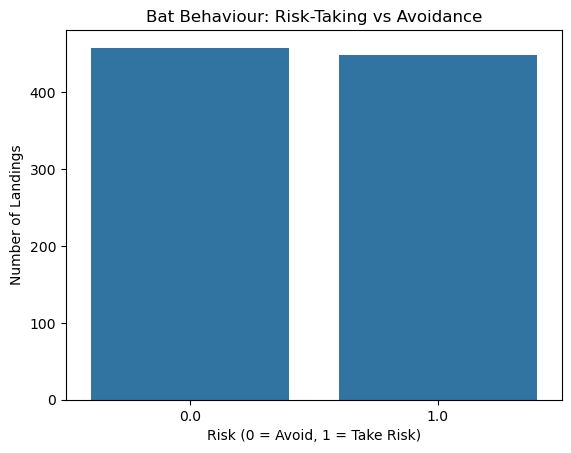

In [14]:
sns.countplot(data=df1, x='risk')
plt.title("Bat Behaviour: Risk-Taking vs Avoidance")
plt.xlabel("Risk (0 = Avoid, 1 = Take Risk)")
plt.ylabel("Number of Landings")
plt.show()

## Do Risk-Taking Bats Get Rewarded?  
This chart compares how often bats were rewarded with food based on whether they took risks or not.  
It helps us see if risk-taking actually increases the chance of getting food.

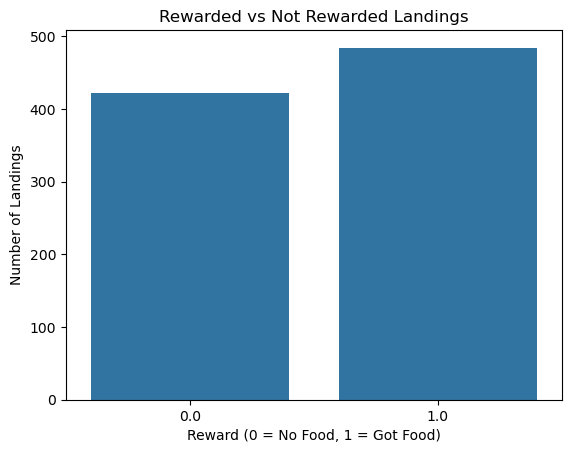

In [15]:
sns.countplot(data=df1, x='reward')
plt.title("Rewarded vs Not Rewarded Landings")
plt.xlabel("Reward (0 = No Food, 1 = Got Food)")
plt.ylabel("Number of Landings")
plt.show()

## Boxplot: Seconds after rat arrival by risk level
This boxplot shows how long bats waited after rats arrived before landing, split by risk behaviour.  
If risk-takers land sooner, it suggests bolder behaviour around rats.

In [16]:
if "sec_since_rat_arrival" in df1.columns:
    sns.boxplot(data=df1, x="risk", y="sec_since_rat_arrival")
    plt.title("Do Risk-Takers Land Sooner After Rat Arrival?")
    plt.xlabel("Risk Behaviour")
    plt.ylabel("Seconds Since Rat Arrival")
    plt.show()

## Risk Behaviour in Different Seasons
This chart shows how bat risk behaviour changes across seasons.  
It helps us check if bats behave differently in spring, summer, winter, or autumn.

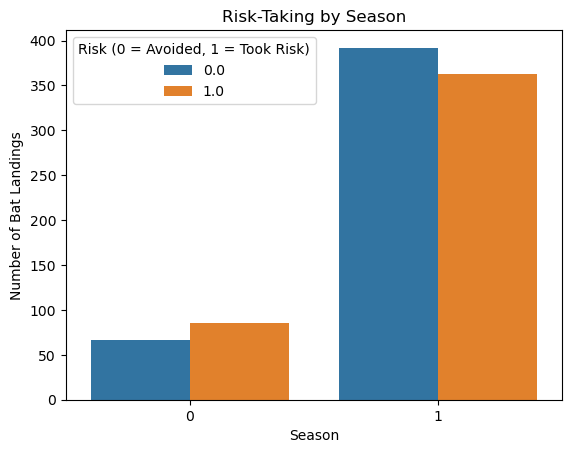

In [17]:
# Risk-Taking by Season

sns.countplot(data=df1, x='season', hue='risk')
plt.title("Risk-Taking by Season")
plt.xlabel("Season")
plt.ylabel("Number of Bat Landings")
plt.legend(title="Risk (0 = Avoided, 1 = Took Risk)")
plt.show()

This boxplot shows how long bats waited after rats arrived before landing, split by risk behaviour.  
If risk-takers land sooner, it suggests bolder behaviour around rats.

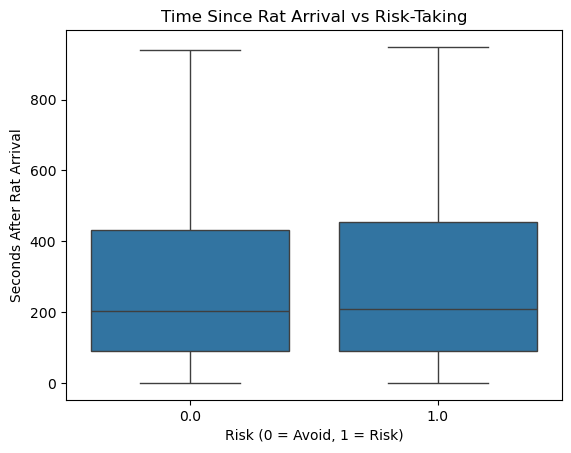

In [18]:
# Time After Rat Arrival vs Risk (Boxplot)

sns.boxplot(data=df1, x='risk', y='seconds_after_rat_arrival')
plt.title("Time Since Rat Arrival vs Risk-Taking")
plt.xlabel("Risk (0 = Avoid, 1 = Risk)")
plt.ylabel("Seconds After Rat Arrival")
plt.show()

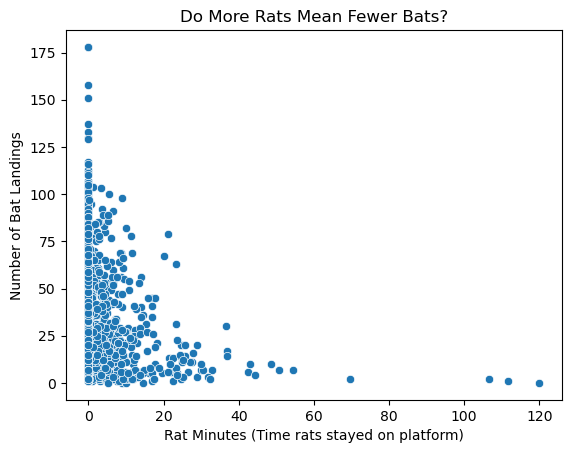

In [19]:
# Rat Presence vs Bat Landings (Scatterplot from dataset2)

sns.scatterplot(data=df2, x='rat_minutes', y='bat_landing_number')
plt.title("Do More Rats Mean Fewer Bats?")
plt.xlabel("Rat Minutes (Time rats stayed on platform)")
plt.ylabel("Number of Bat Landings")
plt.show()

## Are Risk-Takers More Rewarded in Some Seasons?  
This chart shows how often bats were rewarded in each season, separated by their risk behaviour.  
It helps us see if risk is more successful in some seasons than others.

Text(0.5, 0.98, 'How Risk and Season Affect Rewards')

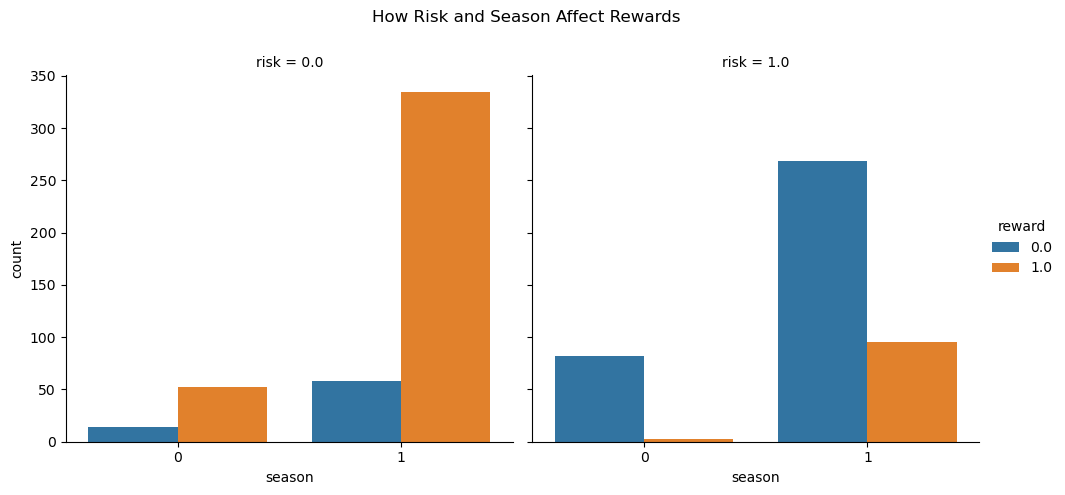

In [20]:
sns.catplot(data=df1, x="season", hue="reward", col="risk", kind="count")
plt.subplots_adjust(top=0.85)
plt.suptitle("How Risk and Season Affect Rewards")

## Which Numeric Features Are Related?  
This heatmap shows how different numeric columns are related to each other.  
It helps us find patterns or connections between timing, risk, reward, and other features.

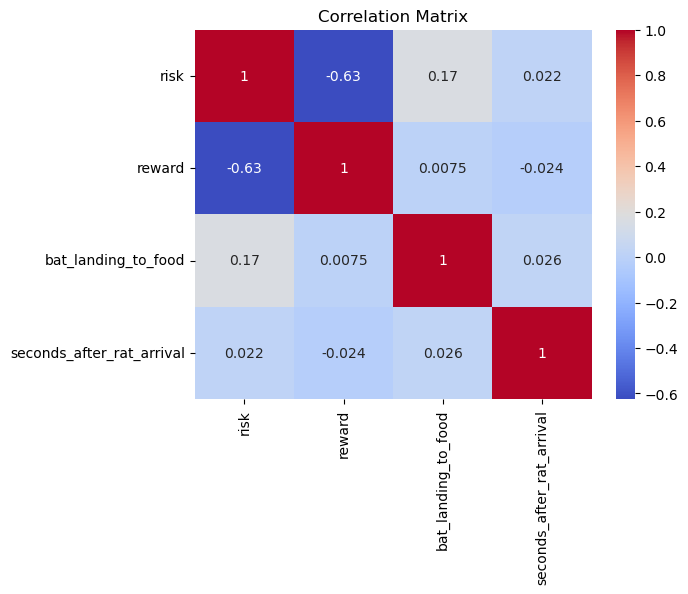

In [21]:
# Correlation Heatmap
sns.heatmap(df1[['risk', 'reward', 'bat_landing_to_food', 'seconds_after_rat_arrival']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Descriptive Analytics
This section summarises the central tendency, spread, distribution shape, and basic relationships in the cleaned datasets.


In [22]:
# ---- helpers ----
def numeric_cols(df):
    return df.select_dtypes(include=np.number).columns.tolist()

def categorical_cols(df):
    return df.select_dtypes(exclude=np.number).columns.tolist()

def show_table(name, tbl):
    print(name)
    display(tbl)

# 1) FULL describe (incl. categorical)
show_table("=== Dataset 1: describe(all) ===", df1.describe(include="all").T)
show_table("=== Dataset 2: describe(all) ===", df2.describe(include="all").T)

# 2) Central tendency & dispersion (numeric only)
num1, num2 = numeric_cols(df1), numeric_cols(df2)

desc1 = pd.DataFrame({
    "Mean": df1[num1].mean(),
    "Median": df1[num1].median(),
    "Std Dev": df1[num1].std(),
    "Min": df1[num1].min(),
    "Max": df1[num1].max(),
    "IQR": df1[num1].quantile(0.75) - df1[num1].quantile(0.25)
}).round(3)

desc2 = pd.DataFrame({
    "Mean": df2[num2].mean(),
    "Median": df2[num2].median(),
    "Std Dev": df2[num2].std(),
    "Min": df2[num2].min(),
    "Max": df2[num2].max(),
    "IQR": df2[num2].quantile(0.75) - df2[num2].quantile(0.25)
}).round(3)

show_table("=== Dataset 1: central tendency & dispersion ===", desc1)
show_table("=== Dataset 2: central tendency & dispersion ===", desc2)

# 3) Distribution shape (skewness & kurtosis)
shape1 = pd.DataFrame({
    "Skewness": df1[num1].skew(),
    "Kurtosis": df1[num1].kurt()
}).round(3)

shape2 = pd.DataFrame({
    "Skewness": df2[num2].skew(),
    "Kurtosis": df2[num2].kurt()
}).round(3)

show_table("=== Dataset 1: distribution shape ===", shape1)
show_table("=== Dataset 2: distribution shape ===", shape2)

# 4) Categorical frequency / proportions (top 10)
for col in categorical_cols(df1):
    freq = (df1[col].value_counts(dropna=False, normalize=True) * 100).round(2).head(10)
    show_table(f"Dataset 1 — Frequency (%) for {col}", freq.to_frame("Proportion %"))

for col in categorical_cols(df2):
    freq = (df2[col].value_counts(dropna=False, normalize=True) * 100).round(2).head(10)
    show_table(f"Dataset 2 — Frequency (%) for {col}", freq.to_frame("Proportion %"))

=== Dataset 1: describe(all) ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
start_time,906,NaN,NaN,NaN,2018-04-11 20:15:47.417218560,2017-12-26 20:57:00,2018-04-03 23:29:00,2018-04-27 00:27:30,2018-05-01 00:07:45,2018-05-31 23:34:00,NaN
bat_landing_to_food,906.0,NaN,NaN,NaN,11.720544,0.010238,1.0,4.0,11.75,443.0,27.658777
habit,906,82,fast,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rat_period_start,906,NaN,NaN,NaN,2018-04-11 20:11:03.841059328,2017-12-26 20:53:00,2018-04-03 23:24:00,2018-04-27 00:24:00,2018-05-01 00:06:00,2018-05-31 23:31:00,NaN
rat_period_end,906,NaN,NaN,NaN,2018-04-11 20:20:14.569536256,2017-12-26 20:58:00,2018-04-03 23:40:00,2018-04-27 00:28:00,2018-05-01 00:09:00,2018-05-31 23:34:00,NaN
seconds_after_rat_arrival,906.0,NaN,NaN,NaN,282.786976,0.0,89.25,206.0,447.25,949.0,241.092545
risk,906.0,NaN,NaN,NaN,0.494481,0.0,0.0,0.0,1.0,1.0,0.500246
reward,906.0,NaN,NaN,NaN,0.534216,0.0,0.0,1.0,1.0,1.0,0.499103
month,906.0,NaN,NaN,NaN,3.800221,0.0,4.0,4.0,5.0,5.0,1.199834
sunset_time,906,NaN,NaN,NaN,2018-04-11 14:44:19.801324544,2017-12-26 16:43:00,2018-04-03 19:01:00,2018-04-26 19:17:00,2018-04-30 19:20:00,2018-05-31 19:41:00,NaN


=== Dataset 2: describe(all) ===


,count,mean,min,25%,50%,75%,max,std
time,2123,2018-03-19 17:54:20.970324992,2017-12-26 16:13:00,2018-02-06 01:03:00,2018-04-04 05:01:00,2018-04-30 23:35:00,2018-06-01 05:41:00,NaN
month,2123.0,3.083844,0.0,2.0,4.0,4.0,6.0,1.642261
hours_after_sunset,1911.0,5.973574,0.0,3.0,6.0,9.0,13.5,3.660845
bat_landing_number,2123.0,32.083373,0.0,11.0,27.0,48.0,178.0,25.614431
food_availability,2123.0,2.445874,0.0,1.962206,2.951877,3.105873,4.0,1.218353
rat_minutes,2123.0,1.994442,0.0,0.0,0.0,0.158333,120.0,6.793397
rat_arrival_number,2123.0,0.444654,0.0,0.0,0.0,1.0,17.0,1.019195


=== Dataset 1: central tendency & dispersion ===


...

,Proportion %
rat_period_end,
2018-04-26 22:36:00,3.20
2018-05-01 00:44:00,2.21
2018-04-03 01:21:00,1.99
2018-04-20 00:18:00,1.77
2018-01-28 20:10:00,1.66
2018-04-30 01:44:00,1.55
2018-04-04 00:58:00,1.43
2018-04-29 03:06:00,1.43
2018-04-21 02:18:00,1.43


Dataset 1 — Frequency (%) for sunset_time


,Proportion %
sunset_time,
2018-04-26 19:17:00,11.15
2018-04-28 19:19:00,7.84
2018-04-19 19:12:00,5.85
2018-04-27 19:18:00,5.52
2018-04-30 19:20:00,5.30
2018-04-29 19:19:00,4.53
2018-04-02 19:01:00,4.42
2018-05-03 19:22:00,3.86
2018-04-21 19:14:00,3.75


Dataset 2 — Frequency (%) for time


,Proportion %
time,
2017-12-26 16:13:00,0.05
2018-04-24 01:45:00,0.05
2018-04-24 18:16:00,0.05
2018-04-24 17:46:00,0.05
2018-04-24 17:16:00,0.05
2018-04-24 08:15:00,0.05
2018-04-24 06:45:00,0.05
2018-04-24 06:15:00,0.05
2018-04-24 05:45:00,0.05


<Figure size 640x480 with 0 Axes>

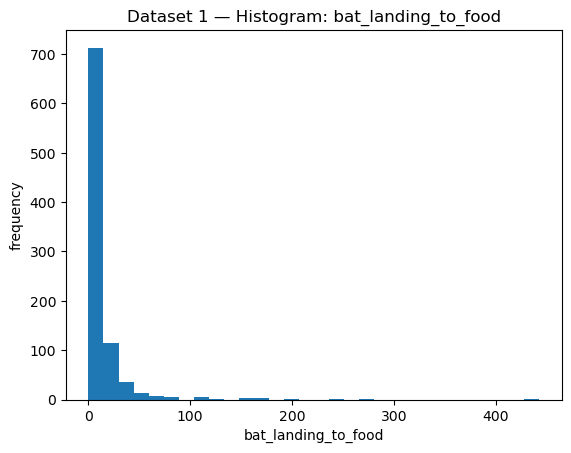

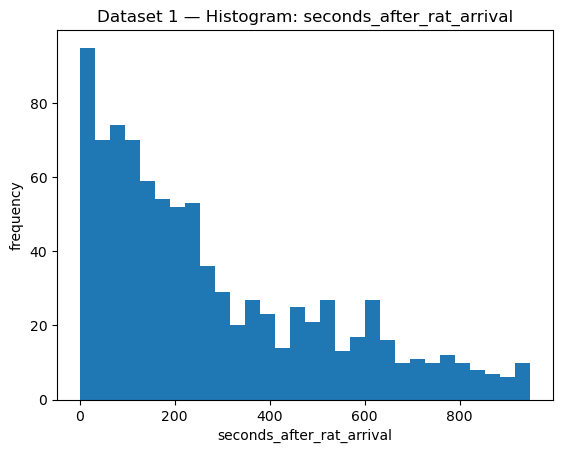

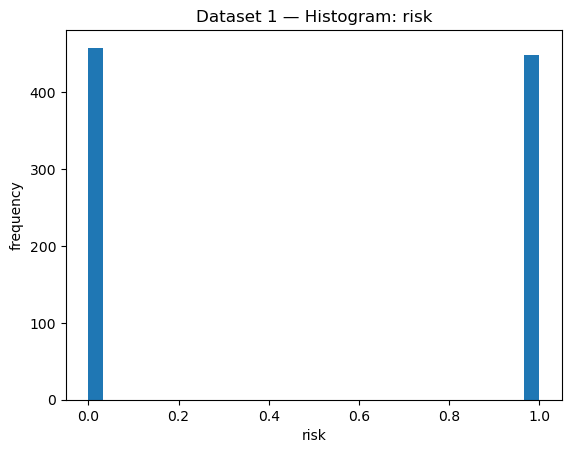

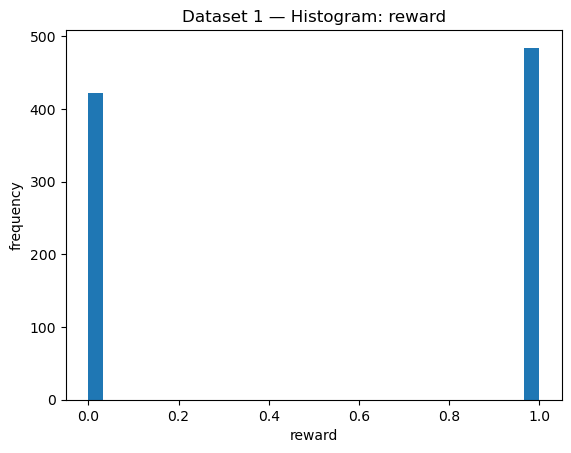

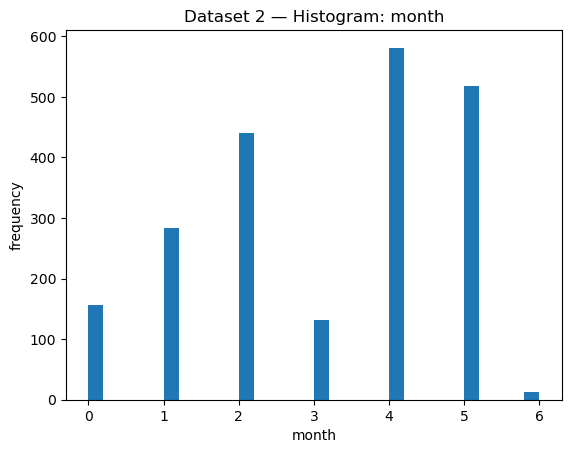

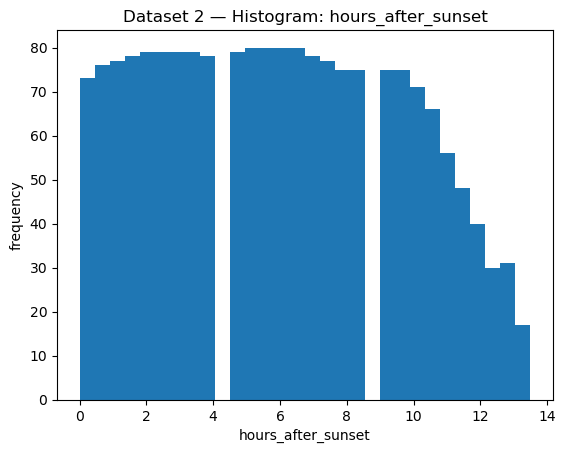

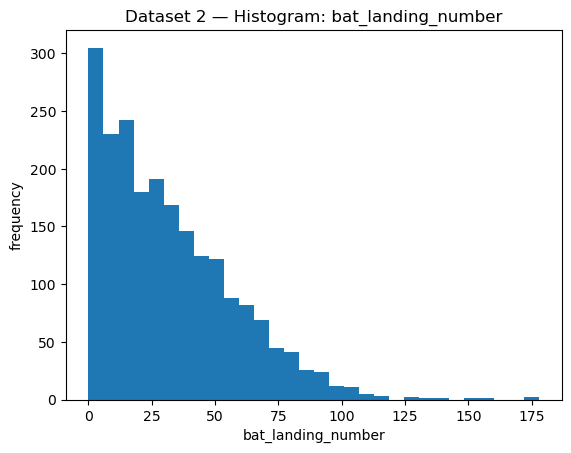

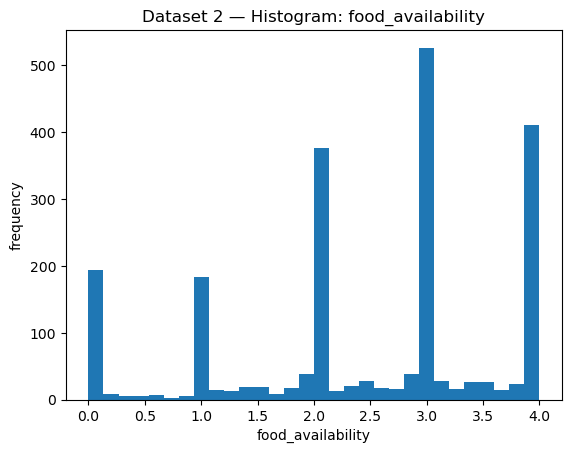

In [23]:
# ---------- HISTOGRAMS ----------
# pick up to 4 numeric columns from each dataset for quick inspection
def first_n(seq, n=4): return seq[:min(n, len(seq))]

plt.figure()
for col in first_n(numeric_cols(df1), 4):
    plt.figure()
    plt.hist(df1[col].dropna(), bins=30)
    plt.title(f"Dataset 1 — Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

for col in first_n(numeric_cols(df2), 4):
    plt.figure()
    plt.hist(df2[col].dropna(), bins=30)
    plt.title(f"Dataset 2 — Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()


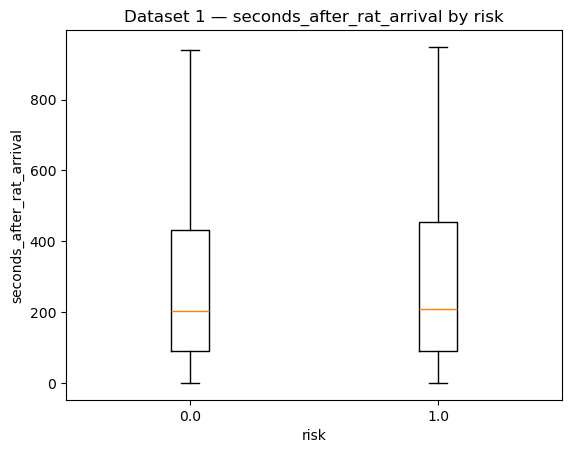

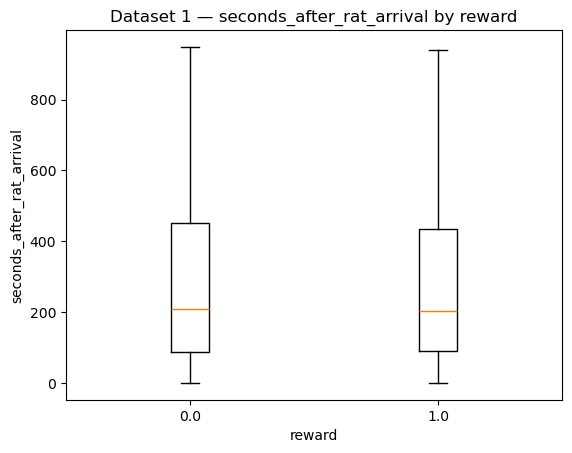

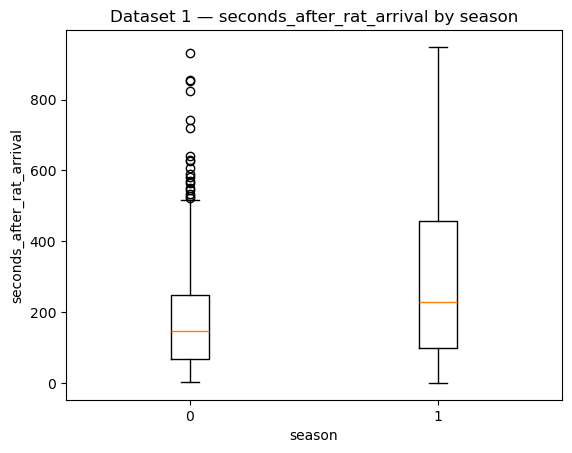

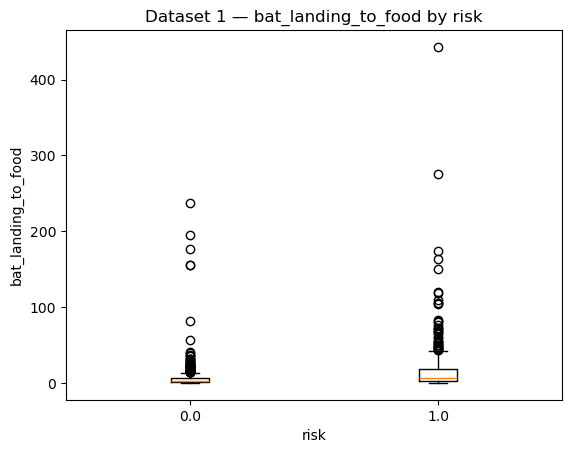

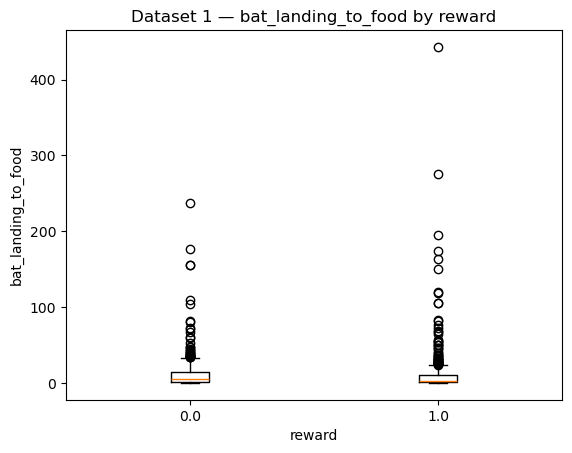

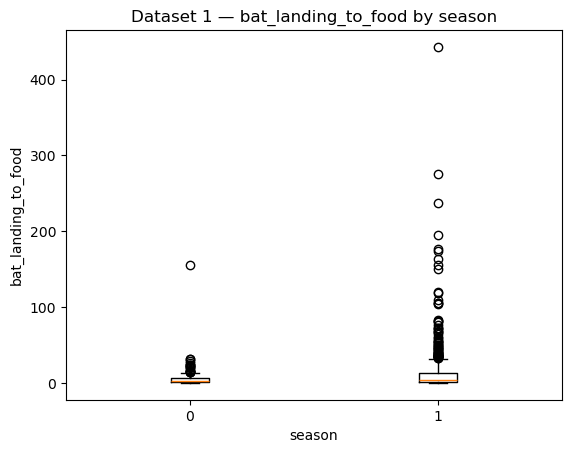

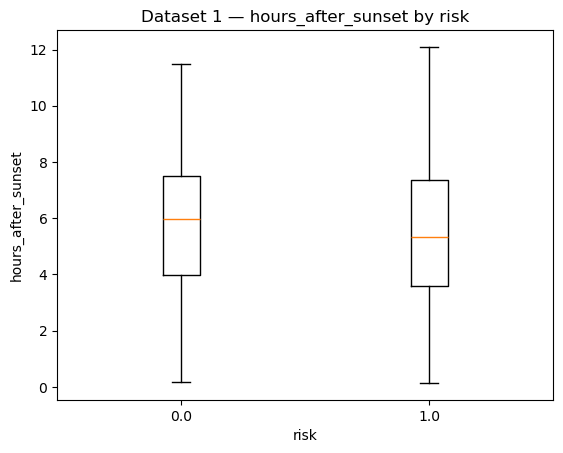

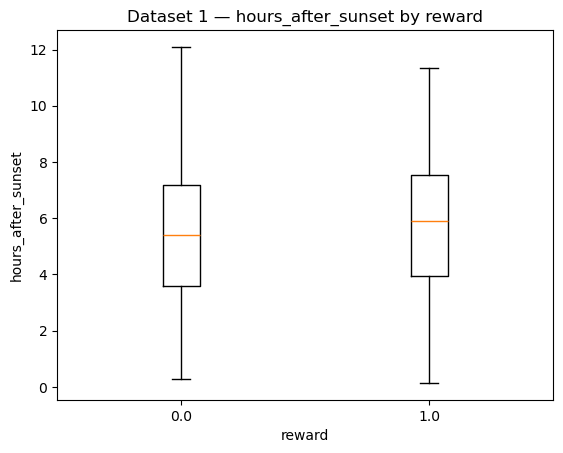

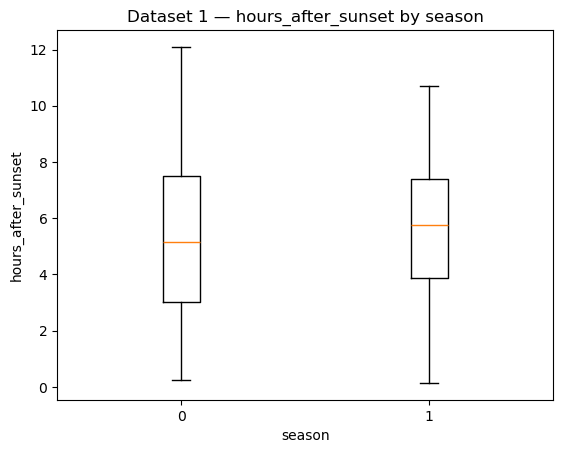

In [26]:
import matplotlib.pyplot as plt

def boxplot_by_category(df, num_col, cat_col, dsname="Dataset"):
    if num_col not in df.columns or cat_col not in df.columns:
        return
    sub = df[[num_col, cat_col]].dropna()
    if sub.empty:
        return

    # Keep categories in a stable, sorted order
    order = sorted(sub[cat_col].unique().tolist())
    groups = [sub.loc[sub[cat_col] == k, num_col].values for k in order]
    tick_labels = [str(k) for k in order]

    plt.figure()
    # Matplotlib 3.9+: use tick_labels (old 'labels' is deprecated)
    plt.boxplot(groups, tick_labels=tick_labels)
    plt.title(f"{dsname} — {num_col} by {cat_col}")
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.show()

# Common combos
candidates_num = ["seconds_after_rat_arrival","bat_landing_to_food","hours_after_sunset",
                  "rat_minutes","bat_landing_number"]
cats = ["risk","reward","season"]

for num_col in candidates_num:
    for cat_col in cats:
        boxplot_by_category(df1, num_col, cat_col, dsname="Dataset 1")
        boxplot_by_category(df2, num_col, cat_col, dsname="Dataset 2")


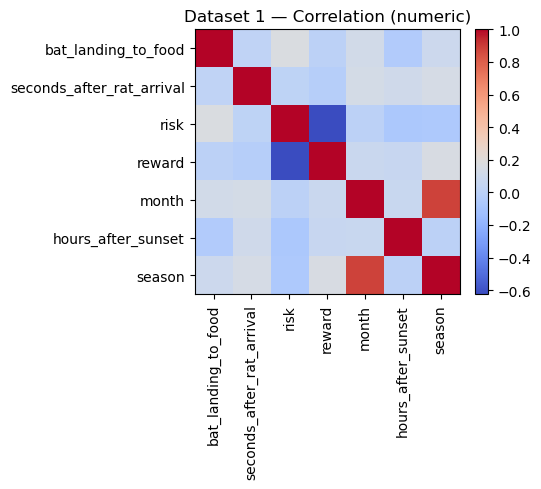

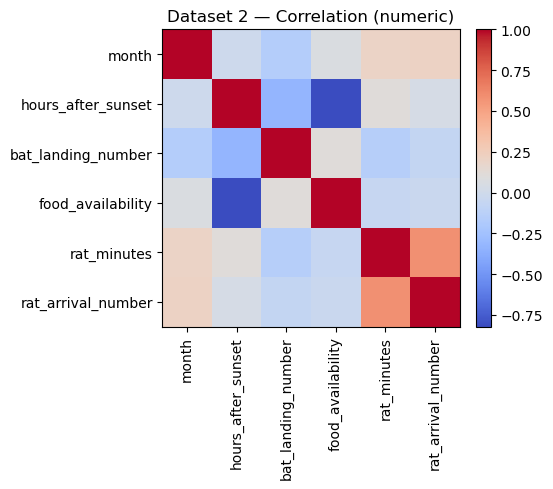

In [25]:
# ---------- CORRELATION HEATMAP (fixed for all pandas versions) ----------

def corr_heatmap(df, title="Correlation (numeric)"):
    # Select only numeric columns manually
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print("No numeric columns for correlation.")
        return
    corr = num.corr()  # removed numeric_only argument
    plt.figure(figsize=(6,5))
    im = plt.imshow(corr, interpolation="nearest", cmap='coolwarm')
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = range(len(corr.columns))
    plt.xticks(ticks, corr.columns, rotation=90)
    plt.yticks(ticks, corr.columns)
    plt.tight_layout()
    plt.show()

corr_heatmap(df1, "Dataset 1 — Correlation (numeric)")
corr_heatmap(df2, "Dataset 2 — Correlation (numeric)")
